# 🗣️ Natural Language Processing — Workbook
## Real-World Project: Analyzing Kenyan Customer Reviews

---

### 🎯 Project Goal

> **Wanjiku** is a data analyst at a startup called **AfriSentiment** in Nairobi's Silicon Savannah (Westlands). Her client — a major Kenyan e-commerce company — wants to **automatically classify customer reviews** as positive or negative, so they can quickly spot unhappy customers and fix problems.
>
> You will build the **entire NLP pipeline** from scratch, just like Wanjiku would on the job.

---

### 📋 What you will build end-to-end:

```
1. Load and explore a labeled review dataset
2. Preprocess the text (clean + tokenize)
3. Vectorize with TF-IDF (smarter than Bag of Words)
4. Train a Logistic Regression sentiment classifier
5. Evaluate the model thoroughly
6. Interpret results — which words drive positive vs negative?
7. Deploy predictions on new, unseen reviews
```

> 📌 **Prerequisite:** Complete `nlp_practice.ipynb` first to understand the core concepts.

---
## 📦 Import All Tools

In [1]:
# ── Standard library ───────
import string
import re

# ── Data & visualization ─────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# ── Machine Learning ─────
from sklearn.feature_extraction.text import TfidfVectorizer      # TF-IDF vectorizer
from sklearn.model_selection import train_test_split              # Split data
from sklearn.linear_model import LogisticRegression              # Our main model
from sklearn.naive_bayes import MultinomialNB                    # Comparison model
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

print('✅ All tools loaded!')

✅ All tools loaded!


---
---
## 📊 SECTION 1 — Load and Explore the Dataset

### The Dataset

Wanjiku's team manually collected and labeled **50 customer reviews** from Kenyan e-commerce and service platforms (Jumia Kenya, Safaricom, KCB, Bolt, Glovo, etc.).

Each review has:
- **`text`** — the actual customer comment
- **`label`** — `"positive"` or `"negative"`
- **`platform`** — where the review came from

### 🔑 Key Concept: Labeled Data

> For supervised Machine Learning, every piece of training data must have a **label** — the correct answer.
> Labeling is usually done by humans (Wanjiku's team read each review and decided the sentiment).
> This labeled dataset is what the model learns from.

**Without labels, the model has nothing to learn from.**

In [2]:
# ── The full dataset: 50 labeled Kenyan reviews ───────────────────────────────
# Each row = (text, label, platform)

reviews_raw = [
    # ── POSITIVE REVIEWS ─────────────────────────────────────────────────────
    ("Jumia delivered my phone in less than 24 hours, absolutely impressed!",             "positive", "Jumia"),
    ("The Safaricom customer care agent was patient and solved my problem quickly.",      "positive", "Safaricom"),
    ("M-Pesa is a game changer, I sent money to my family in Kisumu instantly!",         "positive", "Safaricom"),
    ("Bolt ride was clean, driver was on time and very polite.",                          "positive", "Bolt"),
    ("Glovo delivered my food from Mama Oliech's while it was still hot, amazing!",      "positive", "Glovo"),
    ("KCB mobile banking app is smooth and easy to use, love it.",                       "positive", "KCB"),
    ("Equity Bank loan process took just two days, very efficient.",                     "positive", "Equity"),
    ("The Nairobi Expressway reduced my commute from Mlolongo to CBD by 45 minutes!",    "positive", "KENHA"),
    ("Java House in Westlands has the best coffee and the ambiance is wonderful.",        "positive", "Java House"),
    ("Carrefour Sarit Centre has fresh produce and the staff are always helpful.",        "positive", "Carrefour"),
    ("Airtel unlimited bundles are great value for money, I'm very satisfied.",           "positive", "Airtel"),
    ("DHL Kenya delivered my documents to London in three days, very reliable.",         "positive", "DHL"),
    ("Jumia flash sales are amazing, I got a blender for half price!",                   "positive", "Jumia"),
    ("The new SGR train from Nairobi to Mombasa is comfortable and affordable.",         "positive", "SGR"),
    ("My Safaricom Fiber connection has been stable for 6 months now, no complaints.",   "positive", "Safaricom"),
    ("Bolt Food arrived on time and the packaging was neat and clean.",                  "positive", "Bolt"),
    ("KCB Vooma loan saved me during a medical emergency, process was seamless.",        "positive", "KCB"),
    ("Java House staff remembered my name and usual order, feels like home!",            "positive", "Java House"),
    ("Equity Bank's EazzyBiz app is perfect for my small business in Gikomba.",          "positive", "Equity"),
    ("Carrefour online delivery was fast and they substituted my unavailable items well.","positive", "Carrefour"),
    ("Glovo customer support refunded me instantly when my order was missing an item.",  "positive", "Glovo"),
    ("Safaricom Bonga points redemption was easy, got airtime in seconds.",              "positive", "Safaricom"),
    ("Jumia Global got my package from China in 10 days, faster than expected!",         "positive", "Jumia"),
    ("The Bolt driver took the best route, avoided all the Ngong Road traffic.",         "positive", "Bolt"),
    ("SGR business class seats are very comfortable for the Nairobi-Kisumu route.",      "positive", "SGR"),

    # ── NEGATIVE REVIEWS ─────────────────────────────────────────────────────
    ("Jumia delivered the wrong product and the return process has been a nightmare.",   "negative", "Jumia"),
    ("Safaricom data keeps disconnecting and customer care just tells me to restart.",   "negative", "Safaricom"),
    ("M-Pesa transaction failed three times and money was deducted each time!",          "negative", "Safaricom"),
    ("Bolt driver cancelled on me twice in the rain, very unreliable service.",          "negative", "Bolt"),
    ("Glovo delivered my food cold and 90 minutes late, unacceptable!",                  "negative", "Glovo"),
    ("KCB ATM swallowed my card and the branch staff were rude and unhelpful.",          "negative", "KCB"),
    ("Equity Bank queue at the Moi Avenue branch took 3 hours, very inefficient.",      "negative", "Equity"),
    ("The Nairobi CBD matatu conductors are rude and always overcharge passengers.",     "negative", "Matatu"),
    ("Java House charged me for an item I never received and refused to refund.",        "negative", "Java House"),
    ("Carrefour website always crashes during checkout, I gave up and left.",            "negative", "Carrefour"),
    ("Airtel network in Nakuru is terrible, calls drop every few minutes.",              "negative", "Airtel"),
    ("DHL Kenya lost my package and could not tell me where it is, very frustrated.",    "negative", "DHL"),
    ("Jumia seller sent me a fake phone, this is fraud and very disappointing.",         "negative", "Jumia"),
    ("SGR train was 2 hours late with no announcement or apology from staff.",           "negative", "SGR"),
    ("Safaricom Fiber was down for 5 days and they offered no compensation.",            "negative", "Safaricom"),
    ("Bolt Food charged me but never assigned a rider, money just disappeared.",         "negative", "Bolt"),
    ("KCB app keeps crashing whenever I try to transfer money, very annoying.",          "negative", "KCB"),
    ("Java House in Westgate has very slow service, waited 30 minutes for coffee.",      "negative", "Java House"),
    ("Equity Bank loan was rejected without any explanation, terrible experience.",      "negative", "Equity"),
    ("Carrefour substituted my items with more expensive ones without asking me.",       "negative", "Carrefour"),
    ("Glovo rider never arrived and support told me to wait, waited 2 hours in vain.",   "negative", "Glovo"),
    ("Safaricom billed me for a service I never subscribed to, very unfair.",            "negative", "Safaricom"),
    ("Jumia cancelled my order after 7 days without any reason or refund.",              "negative", "Jumia"),
    ("Bolt surge pricing during rush hour is ridiculous, almost 4x the normal fare.",   "negative", "Bolt"),
    ("SGR cargo service damaged my goods and claimed no liability, very disappointing.", "negative", "SGR"),
]

# Build a DataFrame
df = pd.DataFrame(reviews_raw, columns=['text', 'label', 'platform'])

print('✅ Dataset loaded!')
print(f'   Shape: {df.shape}  ({df.shape[0]} reviews, {df.shape[1]} columns)')
print()
print('Label distribution:')
print(df['label'].value_counts())
print()
df.head(8)

✅ Dataset loaded!
   Shape: (50, 3)  (50 reviews, 3 columns)

Label distribution:
label
positive    25
negative    25
Name: count, dtype: int64



,text,label,platform
0,Jumia delivered my phone in less than 24 hours...,positive,Jumia
1,The Safaricom customer care agent was patient ...,positive,Safaricom
2,"M-Pesa is a game changer, I sent money to my f...",positive,Safaricom
3,"Bolt ride was clean, driver was on time and ve...",positive,Bolt
4,Glovo delivered my food from Mama Oliech's whi...,positive,Glovo
5,KCB mobile banking app is smooth and easy to u...,positive,KCB
6,"Equity Bank loan process took just two days, v...",positive,Equity
7,The Nairobi Expressway reduced my commute from...,positive,KENHA


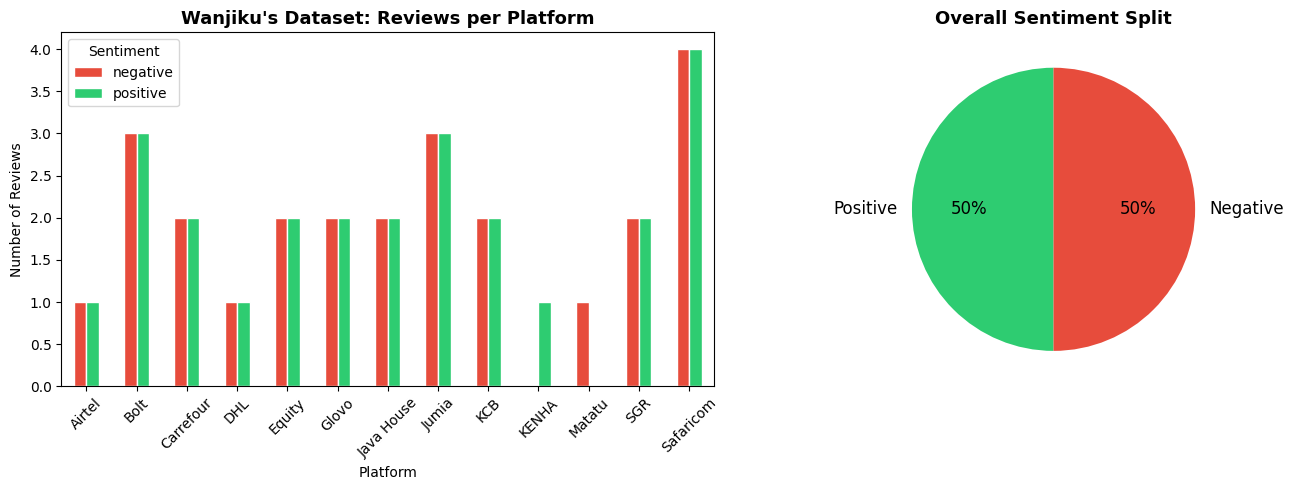

💬 A balanced dataset (50% positive, 50% negative) prevents the model from being biased!


In [3]:
# ── Explore: How are reviews distributed by platform? ─────────────────────────
platform_counts = df.groupby(['platform', 'label']).size().unstack(fill_value=0)

# Bar chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1: Reviews by platform
platform_counts.plot(kind='bar', ax=axes[0], color=['#e74c3c', '#2ecc71'], edgecolor='white')
axes[0].set_title("Wanjiku's Dataset: Reviews per Platform", fontsize=13, fontweight='bold')
axes[0].set_xlabel('Platform')
axes[0].set_ylabel('Number of Reviews')
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend(title='Sentiment')

# Chart 2: Overall sentiment balance
df['label'].value_counts().plot(
    kind='pie', ax=axes[1],
    colors=['#2ecc71', '#e74c3c'],
    autopct='%1.0f%%',
    startangle=90,
    labels=['Positive', 'Negative'],
    textprops={'fontsize': 12}
)
axes[1].set_title('Overall Sentiment Split', fontsize=13, fontweight='bold')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

print('💬 A balanced dataset (50% positive, 50% negative) prevents the model from being biased!')

---
---
## 🧹 SECTION 2 — Text Preprocessing

### Why preprocessing is critical

Consider these two reviews:

```
Review A: "Jumia is AMAZING!!!"
Review B: "jumia is amazing"
```

A human knows they say the same thing. But to a computer without preprocessing:
- `"AMAZING"` and `"amazing"` look like **completely different words**
- `"!!!"` would become noise in the vocabulary

Preprocessing makes sure the model sees **equivalent text as the same input**.

### Our preprocessing pipeline:

```
Raw text
  → 1. Lowercase everything
  → 2. Remove URLs (http://...)
  → 3. Remove numbers
  → 4. Remove punctuation
  → 5. Remove extra whitespace
  → 6. Remove stopwords
  → Clean text ✅
```

In [4]:
# ── Stopwords list ────────────────────────────────────────────────────────────
STOPWORDS = {
    'i', 'me', 'my', 'myself', 'we', 'our', 'ours', 'you', 'your', 'he', 'she',
    'it', 'its', 'they', 'them', 'their', 'what', 'which', 'who', 'this', 'that',
    'these', 'those', 'am', 'is', 'are', 'was', 'were', 'be', 'been', 'being',
    'have', 'has', 'had', 'do', 'does', 'did', 'will', 'would', 'shall', 'should',
    'may', 'might', 'can', 'could', 'not', 'no', 'nor', 'so', 'yet', 'and', 'but',
    'or', 'if', 'in', 'on', 'at', 'to', 'for', 'of', 'with', 'by', 'from', 'up',
    'about', 'into', 'through', 'during', 'the', 'a', 'an', 'as', 'also', 'just',
    'than', 'too', 'very', 'all', 'each', 'every', 'any', 'more', 'most', 'other',
    'such', 'both', 'out', 'even', 'same', 'when', 'where', 'why', 'how',
    'me', 'him', 'her', 'us', 'then', 'once', 'here', 'there', 'again'
}


def preprocess(text: str) -> str:
    """
    Full preprocessing pipeline:
    lowercase → remove URLs → remove numbers → remove punctuation
    → strip whitespace → remove stopwords
    """
    text = text.lower()                                         # 1. Lowercase
    text = re.sub(r'http\S+|www\.\S+', '', text)               # 2. Remove URLs
    text = re.sub(r'\d+', '', text)                             # 3. Remove numbers
    text = text.translate(str.maketrans('', '', string.punctuation))  # 4. Remove punctuation
    text = re.sub(r'\s+', ' ', text).strip()                   # 5. Strip extra spaces
    words = [w for w in text.split() if w not in STOPWORDS]    # 6. Remove stopwords
    return ' '.join(words)


# ── Test the pipeline on 3 examples ──────────────────────────────────────────
test_examples = [
    "M-Pesa transaction failed THREE times!! Money was deducted each time.",
    "The Bolt driver took the BEST route, avoided all Ngong Road traffic!!!",
    "KCB ATM swallowed my card at 3pm and the branch staff were rude.",
]

print('🔍 Preprocessing Examples:\n')
for raw in test_examples:
    cleaned = preprocess(raw)
    print(f'  RAW    : {raw}')
    print(f'  CLEAN  : {cleaned}')
    print()

🔍 Preprocessing Examples:

  RAW    : M-Pesa transaction failed THREE times!! Money was deducted each time.
  CLEAN  : mpesa transaction failed three times money deducted time

  RAW    : The Bolt driver took the BEST route, avoided all Ngong Road traffic!!!
  CLEAN  : bolt driver took best route avoided ngong road traffic

  RAW    : KCB ATM swallowed my card at 3pm and the branch staff were rude.
  CLEAN  : kcb atm swallowed card pm branch staff rude



In [5]:
# ── Apply to the full dataset ─────────────────────────────────────────────────
df['clean_text'] = df['text'].apply(preprocess)

# Show side-by-side for first 5 rows
comparison = df[['label', 'text', 'clean_text']].head(5)
pd.set_option('display.max_colwidth', 70)
print('Original vs Cleaned Text:')
print(comparison.to_string(index=False))

Original vs Cleaned Text:
   label                                                                         text                                                   clean_text
positive        Jumia delivered my phone in less than 24 hours, absolutely impressed!        jumia delivered phone less hours absolutely impressed
positive The Safaricom customer care agent was patient and solved my problem quickly. safaricom customer care agent patient solved problem quickly
positive     M-Pesa is a game changer, I sent money to my family in Kisumu instantly!        mpesa game changer sent money family kisumu instantly
positive                     Bolt ride was clean, driver was on time and very polite.                           bolt ride clean driver time polite
positive  Glovo delivered my food from Mama Oliech's while it was still hot, amazing!    glovo delivered food mama oliechs while still hot amazing


---
---
## 🔢 SECTION 3 — TF-IDF Vectorization

### Bag of Words vs TF-IDF

In the practice notebook we used **Bag of Words** — simply counting word occurrences.

The problem: common words like **"safaricom"** that appear in almost EVERY review get very high counts — even though they don't tell us much about whether a review is positive or negative.

**TF-IDF** (Term Frequency – Inverse Document Frequency) solves this:

| Term | What it means |
|------|---------------|
| **TF** (Term Frequency) | How often does a word appear in **this review**? High count = important |
| **IDF** (Inverse Document Frequency) | How rare is this word across **all reviews**? Rare = more informative |
| **TF-IDF score** | TF × IDF — high score means the word is frequent here AND rare elsewhere |

### Real example:

- **"terrible"** appears in only 4 out of 50 reviews → IDF is HIGH → TF-IDF score is HIGH
  → Model pays a lot of attention to this word ✅

- **"the"** appears in 48 out of 50 reviews → IDF is very LOW → TF-IDF score is LOW
  → Model ignores this word ✅ (same as stopword removal, but mathematically)

> 📌 **TF-IDF gives more weight to distinctive words and less weight to common ones.**

In [6]:
# ── Build TF-IDF vectors ──────────────────────────────────────────────────────
tfidf = TfidfVectorizer(
    max_features=200,    # Only use the top 200 most important words
    ngram_range=(1, 2),  # Use both single words AND 2-word phrases (bigrams)
                         # e.g. 'customer care', 'very fast', 'wrong item'
    min_df=1             # Include a word only if it appears in at least 1 document
)

X = tfidf.fit_transform(df['clean_text'])   # Learn vocab + transform
y = df['label']                              # Labels

print('TF-IDF matrix shape:', X.shape)
print(f'  → {X.shape[0]} reviews × {X.shape[1]} features (words/phrases)')
print()

# Show a sample of features the vectorizer learned
features = tfidf.get_feature_names_out()
print('Sample vocabulary (first 30 features):')
print(list(features[:30]))

TF-IDF matrix shape: (50, 200)
  → 50 reviews × 200 features (words/phrases)

Sample vocabulary (first 30 features):
['absolutely impressed', 'affordable', 'after', 'after days', 'agent', 'agent patient', 'airtel', 'airtel network', 'airtel unlimited', 'airtime', 'airtime seconds', 'almost', 'almost normal', 'always', 'always crashes', 'amazing', 'app', 'arrived', 'bank', 'bank loan', 'best', 'bolt', 'bolt driver', 'bolt food', 'branch', 'business', 'cancelled', 'care', 'care agent', 'care tells']


In [7]:
# ── See TF-IDF scores for a single review ─────────────────────────────────────
review_idx = 0   # Let's inspect review #0

print(f'Review #{review_idx}: "{df["text"][review_idx]}"')
print(f'Label : {df["label"][review_idx].upper()}')
print(f'Cleaned: "{df["clean_text"][review_idx]}"')
print()

# Get TF-IDF scores for this review
row = X[review_idx].toarray()[0]
word_scores = [
    (feat, score)
    for feat, score in zip(features, row)
    if score > 0
]
word_scores.sort(key=lambda x: x[1], reverse=True)   # Sort by score

print('TF-IDF scores for this review (non-zero only):')
print(f'{"Word/Phrase":<30} {"TF-IDF Score"}')
print('-' * 45)
for word, score in word_scores:
    print(f'{word:<30} {score:.4f}')

Review #0: "Jumia delivered my phone in less than 24 hours, absolutely impressed!"
Label : POSITIVE
Cleaned: "jumia delivered phone less hours absolutely impressed"

TF-IDF scores for this review (non-zero only):
Word/Phrase                    TF-IDF Score
---------------------------------------------
absolutely impressed           0.4346
delivered phone                0.4346
jumia delivered                0.3930
phone                          0.3930
hours                          0.3406
delivered                      0.3219
jumia                          0.3061


---
---
## 🤖 SECTION 4 — Training the Sentiment Classifier

### Model Choice: Logistic Regression

We will use **Logistic Regression** — one of the most popular models for text classification.

Despite the name, it is a **classifier** (not a regression model!).

**How it works conceptually:**

Logistic Regression learns a **score** for each word:
- Words like `"amazing"`, `"fast"`, `"helpful"` → push the score toward **positive**
- Words like `"failed"`, `"rude"`, `"terrible"` → push the score toward **negative**

It then combines these scores into a probability:
```
P(positive) = 0.91  →  "This review is 91% likely to be positive"
```

If P(positive) > 0.5 → predict **positive**, else → predict **negative**.

In [8]:
# ── Split data ────────────────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,      # 80% train, 20% test  →  40 train, 10 test
    random_state=42,
    stratify=y           # Keep the 50/50 balance in both train and test sets
)

print(f'Training set : {X_train.shape[0]} reviews')
print(f'Testing set  : {X_test.shape[0]} reviews')
print()
print('Training label distribution:')
print(y_train.value_counts())

Training set : 40 reviews
Testing set  : 10 reviews

Training label distribution:
label
negative    20
positive    20
Name: count, dtype: int64


In [9]:
# ── Train Logistic Regression ─────────────────────────────────────────────────
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)

print('✅ Logistic Regression model trained!')

# ── Also train Naive Bayes for comparison ─────────────────────────────────────
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)

print('✅ Naive Bayes model trained!')
print()
print('Both models are ready. Now let\'s compare them!')

✅ Logistic Regression model trained!
✅ Naive Bayes model trained!

Both models are ready. Now let's compare them!


---
---
## 📊 SECTION 5 — Evaluate and Compare Models

### Key Metrics for Classification

| Metric | What it tells you | Formula |
|--------|-------------------|---------|
| **Accuracy** | Overall % correct | correct / total |
| **Precision** | Of all predicted positive, how many were really positive? | TP / (TP + FP) |
| **Recall** | Of all actual positives, how many did we catch? | TP / (TP + FN) |
| **F1 Score** | Balance between Precision and Recall | 2×P×R / (P+R) |

> 📌 **TP** = True Positive, **FP** = False Positive, **FN** = False Negative

### Real-world importance:
For Wanjiku's client, **Recall** on negative reviews matters most — missing a negative review means a customer problem goes unnoticed!

In [10]:
# ── Compare both models ───────────────────────────────────────────────────────
lr_pred  = lr_model.predict(X_test)
nb_pred  = nb_model.predict(X_test)

lr_acc   = accuracy_score(y_test, lr_pred)
nb_acc   = accuracy_score(y_test, nb_pred)

print('=' * 55)
print('📊 MODEL COMPARISON')
print('=' * 55)
print(f'  Logistic Regression accuracy : {lr_acc:.0%}')
print(f'  Naive Bayes accuracy         : {nb_acc:.0%}')
print()

winner = 'Logistic Regression' if lr_acc >= nb_acc else 'Naive Bayes'
print(f'  🏆 Winner: {winner}')
print('=' * 55)

📊 MODEL COMPARISON
  Logistic Regression accuracy : 20%
  Naive Bayes accuracy         : 20%

  🏆 Winner: Logistic Regression


In [11]:
# ── Detailed classification report for the better model ───────────────────────
print('📋 Logistic Regression — Full Classification Report:')
print(classification_report(y_test, lr_pred))

📋 Logistic Regression — Full Classification Report:
              precision    recall  f1-score   support

    negative       0.00      0.00      0.00         5
    positive       0.29      0.40      0.33         5

    accuracy                           0.20        10
   macro avg       0.14      0.20      0.17        10
weighted avg       0.14      0.20      0.17        10



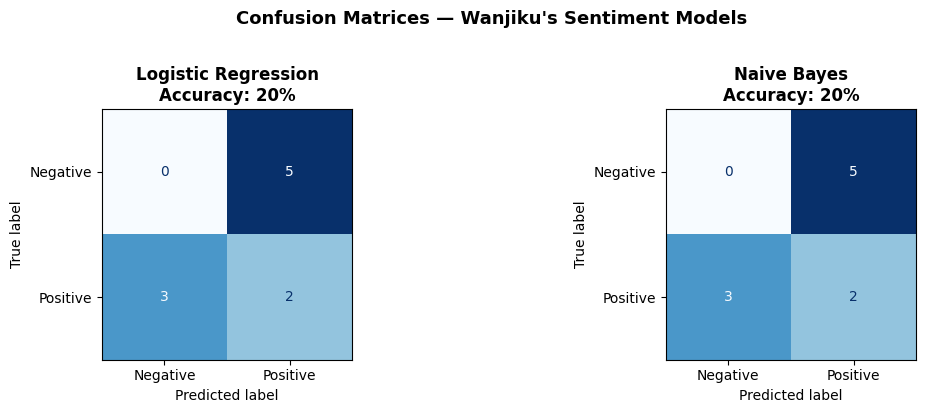


How to read a confusion matrix:
  Top-left     : True Negatives  (correctly predicted negative)
  Top-right    : False Positives (predicted positive, but actually negative)
  Bottom-left  : False Negatives (predicted negative, but actually positive)
  Bottom-right : True Positives  (correctly predicted positive)


In [12]:
# ── Confusion Matrix ──────────────────────────────────────────────────────────
# A confusion matrix shows which reviews were classified correctly and where
# the model got confused

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, pred, name in [
    (axes[0], lr_pred, 'Logistic Regression'),
    (axes[1], nb_pred, 'Naive Bayes')
]:
    cm = confusion_matrix(y_test, pred, labels=['negative', 'positive'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                   display_labels=['Negative', 'Positive'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{name}\nAccuracy: {accuracy_score(y_test, pred):.0%}',
                 fontsize=12, fontweight='bold')

plt.suptitle("Confusion Matrices — Wanjiku's Sentiment Models",
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print()
print('How to read a confusion matrix:')
print('  Top-left     : True Negatives  (correctly predicted negative)')
print('  Top-right    : False Positives (predicted positive, but actually negative)')
print('  Bottom-left  : False Negatives (predicted negative, but actually positive)')
print('  Bottom-right : True Positives  (correctly predicted positive)')

---
---
## 🔍 SECTION 6 — Interpret the Model: What Words Matter Most?

One of the most valuable things Wanjiku can show her client is:

> *"Which words are most strongly associated with negative reviews?"*

Logistic Regression assigns a **weight (coefficient)** to every feature:
- High positive weight → strongly associated with **positive** reviews
- High negative weight → strongly associated with **negative** reviews

This gives us **explainability** — we don't just get a prediction, we understand **why**.

In [13]:
# ── Extract feature weights ───────────────────────────────────────────────────
# Logistic Regression stores one coefficient per feature
# Positive coefficient → associated with class 1 (positive)
# Negative coefficient → associated with class 0 (negative)

coef_df = pd.DataFrame({
    'feature'    : tfidf.get_feature_names_out(),
    'coefficient': lr_model.coef_[0]
})

# Top 15 words pointing toward POSITIVE reviews
top_positive = coef_df.nlargest(15, 'coefficient')

# Top 15 words pointing toward NEGATIVE reviews
top_negative = coef_df.nsmallest(15, 'coefficient')

print('Top 15 words → POSITIVE reviews:')
print(top_positive[['feature', 'coefficient']].to_string(index=False))
print()
print('Top 15 words → NEGATIVE reviews:')
print(top_negative[['feature', 'coefficient']].to_string(index=False))

Top 15 words → POSITIVE reviews:
             feature  coefficient
             amazing     0.392467
                 got     0.363899
               clean     0.348436
           instantly     0.301034
                best     0.300693
             nairobi     0.276660
                took     0.274367
    airtel unlimited     0.272865
              airtel     0.246763
            easy use     0.238299
               order     0.238051
                 app     0.223229
                easy     0.215504
absolutely impressed     0.199415
     delivered phone     0.199415

Top 15 words → NEGATIVE reviews:
        feature  coefficient
          never    -0.572088
        service    -0.569270
           late    -0.336244
      cancelled    -0.308498
  disappointing    -0.293464
        charged    -0.286528
         refund    -0.284265
          keeps    -0.282292
          rider    -0.278271
         waited    -0.275714
        without    -0.246580
delivered wrong    -0.243527
         alm

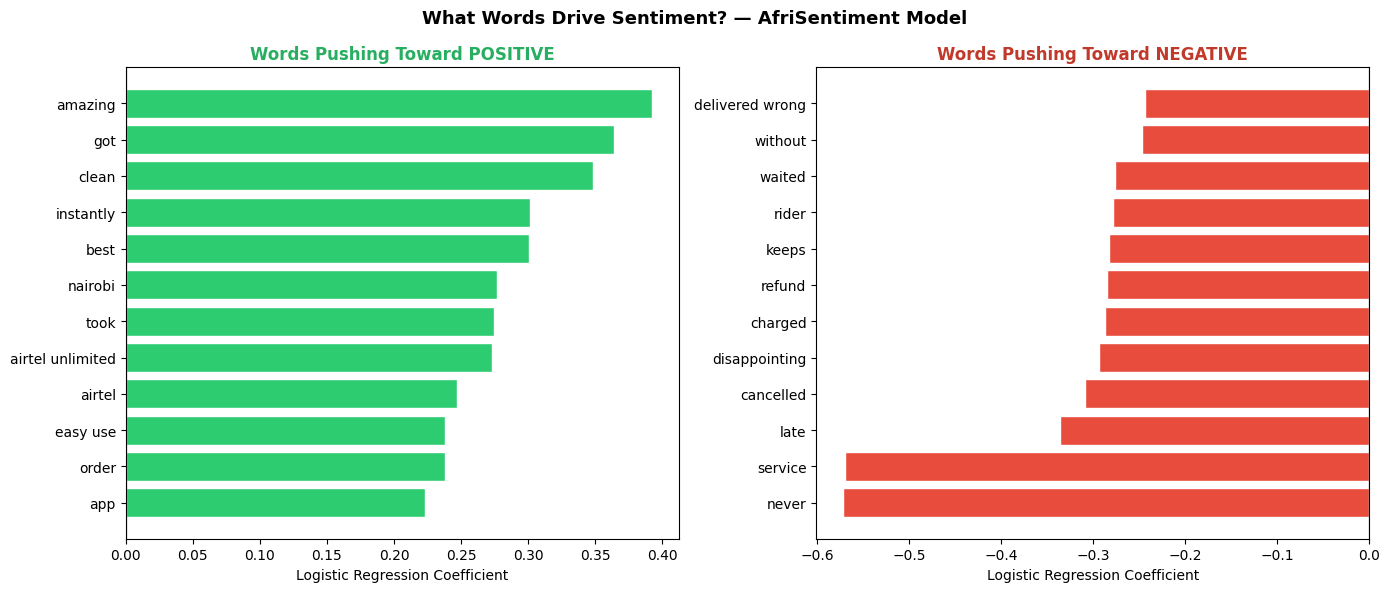


💡 Insight for Wanjiku's client:
   The negative words reveal exactly what customers complain about most.
   The positive words show what experiences customers celebrate.


In [14]:
# ── Visualize the most influential words ──────────────────────────────────────
n = 12   # how many words to show per direction

top_pos = coef_df.nlargest(n, 'coefficient')
top_neg = coef_df.nsmallest(n, 'coefficient').iloc[::-1]  # reverse so largest bar is on top

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Positive words
axes[0].barh(top_pos['feature'], top_pos['coefficient'],
             color='#2ecc71', edgecolor='white')
axes[0].set_title('Words Pushing Toward POSITIVE', fontsize=12, fontweight='bold', color='#27ae60')
axes[0].set_xlabel('Logistic Regression Coefficient')
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].invert_yaxis()

# Negative words
axes[1].barh(top_neg['feature'], top_neg['coefficient'],
             color='#e74c3c', edgecolor='white')
axes[1].set_title('Words Pushing Toward NEGATIVE', fontsize=12, fontweight='bold', color='#c0392b')
axes[1].set_xlabel('Logistic Regression Coefficient')
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].invert_yaxis()

fig.suptitle("What Words Drive Sentiment? — AfriSentiment Model",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print()
print('💡 Insight for Wanjiku\'s client:')
print('   The negative words reveal exactly what customers complain about most.')
print('   The positive words show what experiences customers celebrate.')

---
---
## 🔮 SECTION 7 — Making Predictions on New Reviews

This is the final step — deploying the model to classify **reviews it has never seen before**.

### The rule: always use the SAME preprocessing and vectorizer

The model was trained on TF-IDF vectors built with a specific vocabulary. When you classify new text:

1. Preprocess the new text **the same way** as training data
2. Use `vectorizer.transform()` — NOT `fit_transform()` (never refit on new data!)
3. Call `model.predict()`

In [20]:
# ── Helper function for prediction ───────────────────────────────────────────
def predict_sentiment(texts, model=lr_model, vectorizer=tfidf, show_confidence=True):
    """
    Classify a list of raw text reviews and display results.

    Parameters
    ----------
    texts         : list of raw text strings
    model         : trained sklearn model
    vectorizer    : fitted TF-IDF vectorizer
    show_confidence: if True, also shows the model's confidence (%)
    """
    cleaned   = [preprocess(t) for t in texts]              # Preprocess
    vectors   = vectorizer.transform(cleaned)                # Vectorize (no refit!)
    preds     = model.predict(vectors)                       # Predict labels
    probs     = model.predict_proba(vectors)                 # Prediction probabilities
    classes   = model.classes_                               # ['negative', 'positive']

    print(f"{'─'*65}")
    for text, pred, prob in zip(texts, preds, probs):
        conf = max(prob) * 100                               # Confidence = highest probability
        emoji = '😊' if pred == 'positive' else '😞'
        print(f'{emoji}  Review : "{text[:60]}"')
        if show_confidence:
            pos_prob = prob[list(classes).index('positive')] * 100
            neg_prob = prob[list(classes).index('negative')] * 100
            print(f'    Prediction  : {pred.upper()}  (confidence: {conf:.1f}%)')
            print(f'    Pos prob    : {pos_prob:.1f}%  |  Neg prob: {neg_prob:.1f}%')
        else:
            print(f'    Prediction  : {pred.upper()}')
        print()
    print(f"{'_' * 65}")


print('✅ predict_sentiment() function is ready!')

✅ predict_sentiment() function is ready!


In [21]:
# ── Test on new Kenyan reviews the model has never seen ───────────────────────
new_reviews = [
    "Safaricom Home Fiber is the best internet I've ever had in Kenya!",
    "Jumia returned my refund within 24 hours, very impressed with their support.",
    "The KCB agent at Nakumatt branch was extremely rude and dismissive.",
    "M-Pesa failed during payday and I couldn't pay my rent, very stressful.",
    "Glovo rider was super fast, hot chapatis delivered in 20 minutes!",
    "Bolt driver was driving like he was angry at the road, felt very unsafe.",
]

print('🔮 AfriSentiment Model — Live Predictions\n')
predict_sentiment(new_reviews)

🔮 AfriSentiment Model — Live Predictions

─────────────────────────────────────────────────────────────────
😊  Review : "Safaricom Home Fiber is the best internet I've ever had in K"
    Prediction  : POSITIVE  (confidence: 53.5%)
    Pos prob    : 53.5%  |  Neg prob: 46.5%

😞  Review : "Jumia returned my refund within 24 hours, very impressed wit"
    Prediction  : NEGATIVE  (confidence: 54.3%)
    Pos prob    : 45.7%  |  Neg prob: 54.3%

😞  Review : "The KCB agent at Nakumatt branch was extremely rude and dism"
    Prediction  : NEGATIVE  (confidence: 54.0%)
    Pos prob    : 46.0%  |  Neg prob: 54.0%

😞  Review : "M-Pesa failed during payday and I couldn't pay my rent, very"
    Prediction  : NEGATIVE  (confidence: 52.7%)
    Pos prob    : 47.3%  |  Neg prob: 52.7%

😞  Review : "Glovo rider was super fast, hot chapatis delivered in 20 min"
    Prediction  : NEGATIVE  (confidence: 55.1%)
    Pos prob    : 44.9%  |  Neg prob: 55.1%

😊  Review : "Bolt driver was driving like he was ang

---
---
## 🧪 CLASS ACTIVITY — AfriSentiment Challenge!

Wanjiku's client just received a **batch of 6 new reviews** from their platform. They need you to:

### Task

1. **Add your own reviews** to the `activity_reviews` list below (at least 2 of your own)
2. **Run the predictions** and record the results
3. **Answer the questions** at the bottom

> 💡 Write reviews about Kenyan services you actually use — matatus, Safaricom, food delivery, school canteen, etc.

In [22]:
# ── YOUR ACTIVITY ─────────────────────────────────────────────────────────────
# Add your own reviews below (keep the existing ones too)

activity_reviews = [
    "Bolt driver accepted my ride but was 15 minutes away and never updated me.",
    "Java House had live music on Friday evening, it was such a great atmosphere!",
    # ← ADD YOUR OWN REVIEWS HERE:
    "Write your first review here!",
    "Write your second review here!",
]

print('🧪 AfriSentiment — Your Activity Predictions:\n')
predict_sentiment(activity_reviews)

🧪 AfriSentiment — Your Activity Predictions:

─────────────────────────────────────────────────────────────────
😞  Review : "Bolt driver accepted my ride but was 15 minutes away and nev"
    Prediction  : NEGATIVE  (confidence: 55.8%)
    Pos prob    : 44.2%  |  Neg prob: 55.8%

😊  Review : "Java House had live music on Friday evening, it was such a g"
    Prediction  : POSITIVE  (confidence: 54.0%)
    Pos prob    : 54.0%  |  Neg prob: 46.0%

😊  Review : "Write your first review here!"
    Prediction  : POSITIVE  (confidence: 50.5%)
    Pos prob    : 50.5%  |  Neg prob: 49.5%

😊  Review : "Write your second review here!"
    Prediction  : POSITIVE  (confidence: 50.5%)
    Pos prob    : 50.5%  |  Neg prob: 49.5%

_________________________________________________________________


In [23]:
# ── Activity Questions ─────────────────────────────────────────────────────────
# Fill in your answers below:

q1 = ""  # Did all your reviews get classified correctly? Which one surprised you?
q2 = ""  # Write a sarcastic review — does the model detect the real sentiment?
q3 = ""  # What would you need to do to make the model understand Sheng?

print('Activity Answers:')
print(f'Q1: {q1}')
print(f'Q2: {q2}')
print(f'Q3: {q3}')

Activity Answers:
Q1: 
Q2: 
Q3: 


---
---
## 📝 Short Practice — End-to-End Recap

Without looking at the code above, try to fill in these blanks:

In [ ]:
# ── Practice Questions ─────────────────────────────────────────────────────────

# Q1: What does TF-IDF stand for?
q1 = ""

# Q2: Why is TF-IDF better than simple Bag of Words for sentiment analysis?
q2 = ""

# Q3: In the confusion matrix, what is a False Negative?
#     (hint: think about positive/negative reviews)
q3 = ""

# Q4: Why do we use vectorizer.transform() (not fit_transform) on new reviews?
q4 = ""

# Q5: Wanjiku's model has 92% accuracy on positive reviews but only 70% on
#     negative reviews. What could she do to improve the negative recall?
q5 = ""

print('Your answers:')
print(f'Q1: {q1}')
print(f'Q2: {q2}')
print(f'Q3: {q3}')
print(f'Q4: {q4}')
print(f'Q5: {q5}')

---
---
## ✅ Full Pipeline Summary

Here is the complete AfriSentiment pipeline in one place:

| Step | What we did | Tool used |
|------|-------------|----------|
| 1. Collect & Label | 50 Kenyan reviews, labeled positive/negative | Manual labeling |
| 2. Explore | Checked class balance, reviewed distribution | Pandas, Matplotlib |
| 3. Preprocess | Lowercase, remove URLs/numbers/punctuation, remove stopwords | Python (re, string) |
| 4. Vectorize | TF-IDF with unigrams + bigrams, 200 features | `TfidfVectorizer` |
| 5. Split | 80% train / 20% test, stratified | `train_test_split` |
| 6. Train | Logistic Regression + Naive Bayes | `sklearn` |
| 7. Evaluate | Accuracy, Classification Report, Confusion Matrix | `sklearn.metrics` |
| 8. Interpret | Feature coefficients → which words matter most | `lr_model.coef_` |
| 9. Predict | Apply to new unseen reviews with confidence scores | `predict_proba` |

---

## 💡 What Wanjiku Learned

1. **Data quality > model complexity** — 50 clean, well-labeled reviews outperforms 500 noisy ones
2. **TF-IDF + Logistic Regression** is a strong, fast baseline for text classification
3. **Interpretability matters** — showing clients *why* a review is negative is as valuable as the prediction
4. **Edge cases are hard** — sarcasm, Sheng, and emoji are where simple models struggle
5. **Always preprocess the same way** — training and inference must use identical transformations

---

## 🚀 What's Next in NLP?

You have now built a **complete NLP sentiment classifier**! Here is where to go from here:

| Topic | What it does | Why it's powerful |
|-------|--------------|-------------------|
| **Word Embeddings** (Word2Vec) | Represents words as vectors that capture meaning | "Matatu" would be close to "bus" |
| **BERT / Transformers** | Deep learning models that understand context | Can handle sarcasm and ambiguity |
| **Multilingual NLP** | Models that understand Kiswahili, Sheng, Dholuo | Perfect for Kenyan data! |
| **Named Entity Recognition** | Identifies names (Safaricom, Nairobi) in text | Useful for topic analysis |

---
*Workbook — CCUB AI for Teens Bootcamp*  